# Entrenamiento con Transformación Logarítmica — Predicción de Dengue## Universidad de El Salvador — IngenieríaEste notebook repite el entrenamiento de los tres modelos (Regresión Lineal, Random Forest,XGBoost) pero aplicando una **transformación logarítmica** a la variable objetivo.**¿Por qué transformar?**La variable `casos_total` está muy sesgada hacia cero (la mayoría de semanas tienen 0-2 casos,con pocos valores extremos). La transformación `log(casos + 1)` comprime los valores grandesy expande los pequeños, ayudando al modelo a aprender mejor los cambios en el rango bajo,que es donde vive la mayoría de los datos.**Puntos clave del método:**- Se usa `log1p(x) = log(x + 1)` para manejar los ceros (log(0) es indefinido)- Se entrena y predice en escala logarítmica- Se revierte con `expm1(x) = exp(x) - 1` para evaluar en casos reales- La división es la misma que antes: Train (2015-2021), Val (2022), Test (2023)

## 1. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('Librerías cargadas')

Librerías cargadas


## 2. Carga de datos desde GitHub

In [ ]:
BASE = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/'

train = pd.read_csv(BASE + 'dataset_train.csv')
val   = pd.read_csv(BASE + 'dataset_val.csv')
test  = pd.read_csv(BASE + 'dataset_test.csv')
deptos = pd.read_csv(BASE + 'tabla%20departamentos.csv')

print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')

Train: (4233, 45) | Val: (472, 45) | Test: (312, 45)


## 3. Integrar ID de departamento

In [ ]:
def agregar_id(df, tabla):
    return df.merge(tabla, on='departamento', how='left')

train = agregar_id(train, deptos)
val   = agregar_id(val, deptos)
test  = agregar_id(test, deptos)

print('Nulos en id:', train['id'].isna().sum(), val['id'].isna().sum(), test['id'].isna().sum())

Nulos en id: 0 0 0


## 4. Selección de variables (igual que antes, evitando fuga)

In [ ]:
OBJETIVO = 'casos_total'
excluir = ['casos_confirmados', 'casos_probables', 'casos_total',
           'anio_epi', 'departamento']
predictoras = [c for c in train.columns if c not in excluir]

print(f'Objetivo: {OBJETIVO}')
print(f'Predictoras: {len(predictoras)}')

Objetivo: casos_total
Predictoras: 41


## 5. Preparar X, y — y aplicar la transformación logarítmicaAquí está el corazón de este notebook. La variable objetivo `y` se transforma con `log1p`.Guardamos también la `y` original (sin transformar) para poder evaluar al final en casos reales.

Ejemplo de transformación (primeros valores de train):
 casos_real  log1p(casos)
          1      0.693147
          1      0.693147
          0      0.000000
          1      0.693147
          1      0.693147
          0      0.000000
          0      0.000000
          1      0.693147


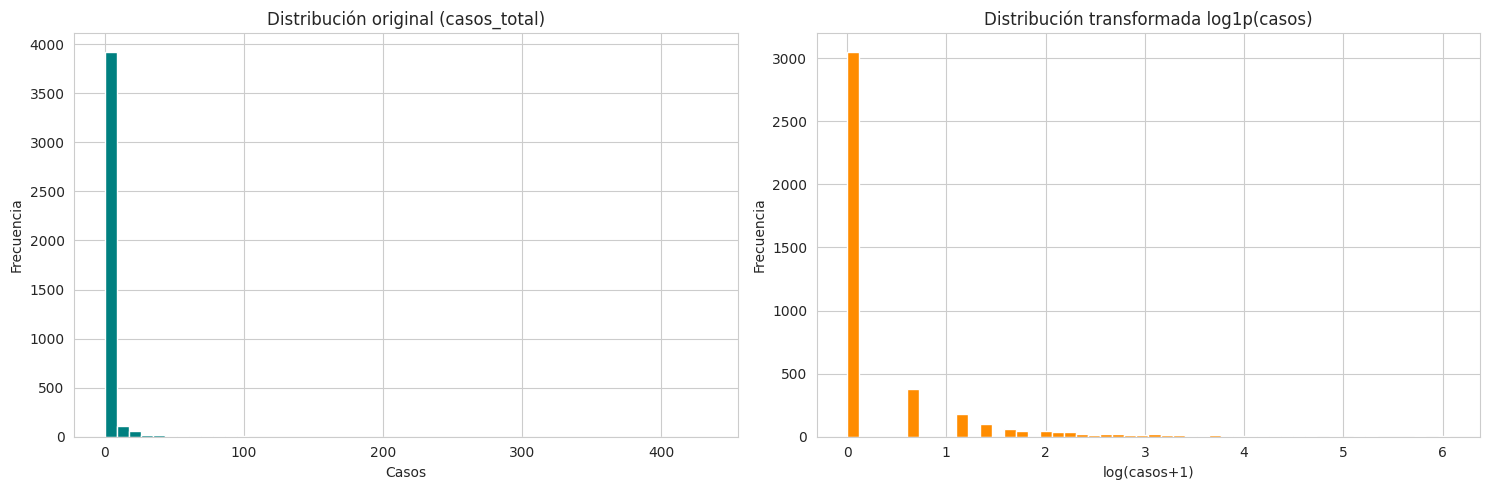

In [ ]:
def preparar(df, predictoras, objetivo):
    X = df[predictoras].copy()
    y = df[objetivo].copy()
    return X, y

X_train, y_train_real = preparar(train, predictoras, OBJETIVO)
X_val,   y_val_real   = preparar(val, predictoras, OBJETIVO)
X_test,  y_test_real  = preparar(test, predictoras, OBJETIVO)

# Limpiar nulos de rezagos en train; rellenar en val/test
mask = X_train.notna().all(axis=1)
X_train, y_train_real = X_train[mask], y_train_real[mask]
X_val  = X_val.fillna(0)
X_test = X_test.fillna(0)

# ── TRANSFORMACIÓN LOGARÍTMICA de la variable objetivo ──
y_train_log = np.log1p(y_train_real)   # log(casos + 1)
y_val_log   = np.log1p(y_val_real)
y_test_log  = np.log1p(y_test_real)

print('Ejemplo de transformación (primeros valores de train):')
comparacion = pd.DataFrame({
    'casos_real': y_train_real.values[:8],
    'log1p(casos)': y_train_log.values[:8]
})
print(comparacion.to_string(index=False))

# Visualizar el efecto de la transformación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(y_train_real, bins=50, color='teal', edgecolor='white')
axes[0].set_title('Distribución original (casos_total)')
axes[0].set_xlabel('Casos'); axes[0].set_ylabel('Frecuencia')
axes[1].hist(y_train_log, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución transformada log1p(casos)')
axes[1].set_xlabel('log(casos+1)'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución transformada (derecha) debería verse menosextrema que la original, aunque seguirá teniendo muchos ceros. La transformación ayudasobre todo a que los valores altos no dominen tanto el aprendizaje.

## 6. Función de evaluaciónImportante: los modelos predicen en escala logarítmica, pero evaluamos en **casos reales**revirtiendo con `expm1`. Así las métricas son interpretables (error en número de casos).

In [ ]:
def evaluar_en_reales(y_real, pred_log, nombre):
    # Revertir la transformación: de log a casos reales
    pred_real = np.expm1(pred_log)
    # Las predicciones no pueden ser negativas
    pred_real = np.clip(pred_real, 0, None)

    mae = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2 = r2_score(y_real, pred_real)
    print(f'{nombre:22s} | MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | R2: {r2:7.3f}')
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}, pred_real

resultados = []

# Baseline en escala real (sin transformación, para comparar)
baseline_pred = np.clip(test['casos_total_lag1'].fillna(0).values, 0, None)
mae_b = mean_absolute_error(y_test_real, baseline_pred)
rmse_b = np.sqrt(mean_squared_error(y_test_real, baseline_pred))
r2_b = r2_score(y_test_real, baseline_pred)
print(f'{"Baseline (lag1)":22s} | MAE: {mae_b:6.3f} | RMSE: {rmse_b:6.3f} | R2: {r2_b:7.3f}')
resultados.append({'modelo': 'Baseline (lag1)', 'MAE': mae_b, 'RMSE': rmse_b, 'R2': r2_b})

Baseline (lag1)        | MAE:  0.631 | RMSE:  2.082 | R2:  -1.061


## 7. Modelo 1 — Regresión Lineal (con objetivo transformado)

In [ ]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train_log)   # entrena sobre y en escala log

pred_lr_test_log = modelo_lr.predict(X_test)

print('=== REGRESIÓN LINEAL (log) ===')
res_lr, pred_lr = evaluar_en_reales(y_test_real, pred_lr_test_log, 'Regresión Lineal (log)')
resultados.append(res_lr)

=== REGRESIÓN LINEAL (log) ===
Regresión Lineal (log) | MAE:  0.609 | RMSE:  1.444 | R2:   0.009


## 8. Modelo 2 — Random Forest (con objetivo transformado)

In [ ]:
modelo_rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
modelo_rf.fit(X_train, y_train_log)

pred_rf_test_log = modelo_rf.predict(X_test)

print('=== RANDOM FOREST (log) ===')
res_rf, pred_rf = evaluar_en_reales(y_test_real, pred_rf_test_log, 'Random Forest (log)')
resultados.append(res_rf)

=== RANDOM FOREST (log) ===
Random Forest (log)    | MAE:  0.473 | RMSE:  1.497 | R2:  -0.065


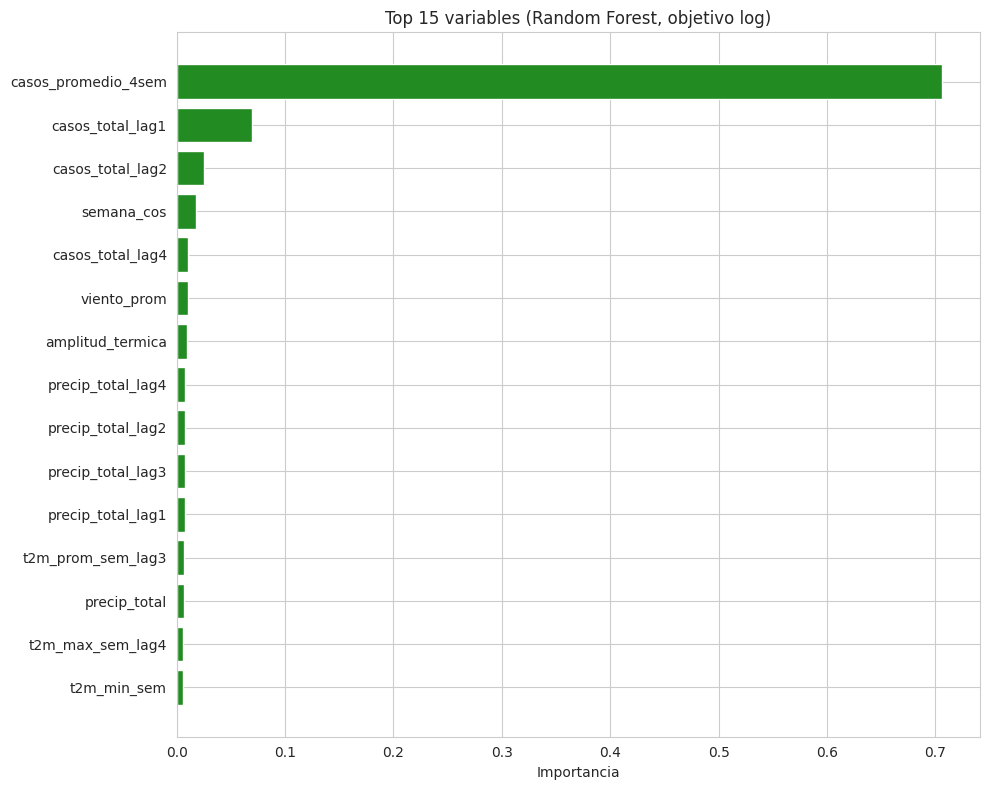

           variable  importancia
casos_promedio_4sem     0.705881
   casos_total_lag1     0.069295
   casos_total_lag2     0.025152
         semana_cos     0.018044
   casos_total_lag4     0.010448
        viento_prom     0.010375
   amplitud_termica     0.009258
  precip_total_lag4     0.007480
  precip_total_lag2     0.007478
  precip_total_lag3     0.007368


In [ ]:
# Importancia de variables
imp_rf = pd.DataFrame({
    'variable': predictoras,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 8))
top15 = imp_rf.head(15)
plt.barh(top15['variable'], top15['importancia'], color='forestgreen')
plt.xlabel('Importancia'); plt.title('Top 15 variables (Random Forest, objetivo log)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(imp_rf.head(10).to_string(index=False))

## 9. Modelo 3 — XGBoost (con objetivo transformado)

In [ ]:
modelo_xgb = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
modelo_xgb.fit(X_train, y_train_log,
               eval_set=[(X_val, y_val_log)], verbose=False)

pred_xgb_test_log = modelo_xgb.predict(X_test)

print('=== XGBOOST (log) ===')
res_xgb, pred_xgb = evaluar_en_reales(y_test_real, pred_xgb_test_log, 'XGBoost (log)')
resultados.append(res_xgb)

=== XGBOOST (log) ===
XGBoost (log)          | MAE:  0.490 | RMSE:  1.511 | R2:  -0.085


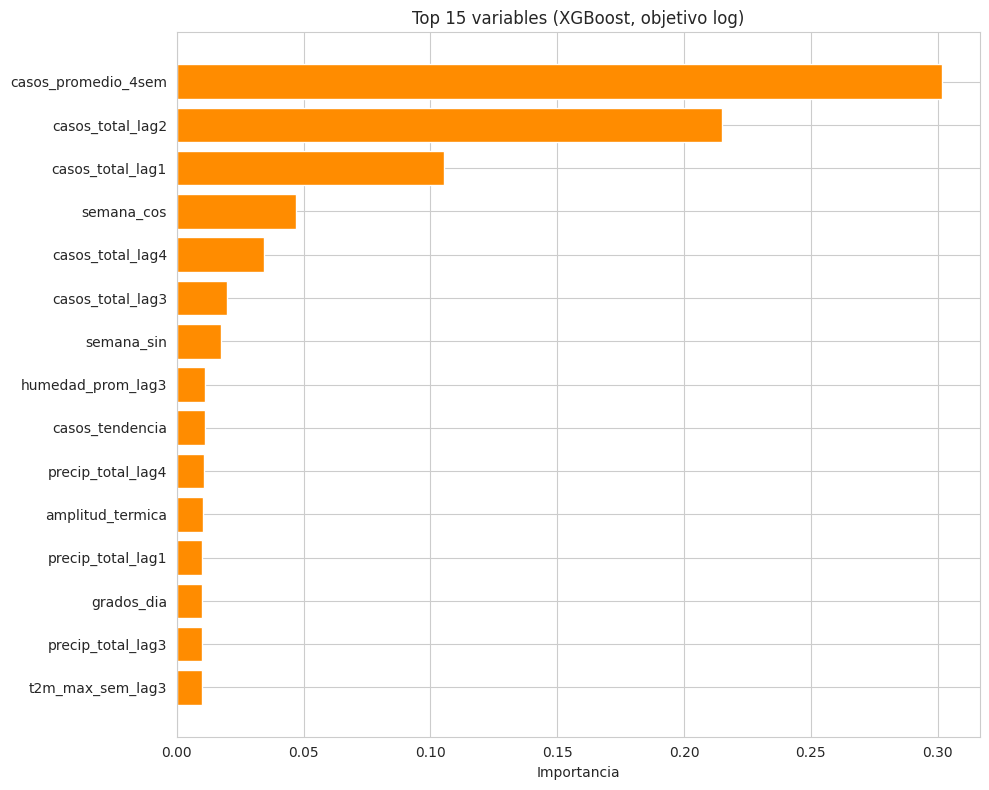

           variable  importancia
casos_promedio_4sem     0.301615
   casos_total_lag2     0.215145
   casos_total_lag1     0.105252
         semana_cos     0.047196
   casos_total_lag4     0.034264
   casos_total_lag3     0.019774
         semana_sin     0.017407
  humedad_prom_lag3     0.011091
    casos_tendencia     0.011024
  precip_total_lag4     0.010723


In [ ]:
imp_xgb = pd.DataFrame({
    'variable': predictoras,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 8))
top15 = imp_xgb.head(15)
plt.barh(top15['variable'], top15['importancia'], color='darkorange')
plt.xlabel('Importancia'); plt.title('Top 15 variables (XGBoost, objetivo log)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(imp_xgb.head(10).to_string(index=False))

## 10. Comparación de modelos (con transformación log)

=== COMPARACIÓN FINAL (Prueba 2023, evaluado en casos reales) ===

                modelo      MAE     RMSE        R2
       Baseline (lag1) 0.631410 2.082436 -1.060567
Regresión Lineal (log) 0.608550 1.444007  0.009208
   Random Forest (log) 0.473242 1.497110 -0.065003
         XGBoost (log) 0.489571 1.510964 -0.084806


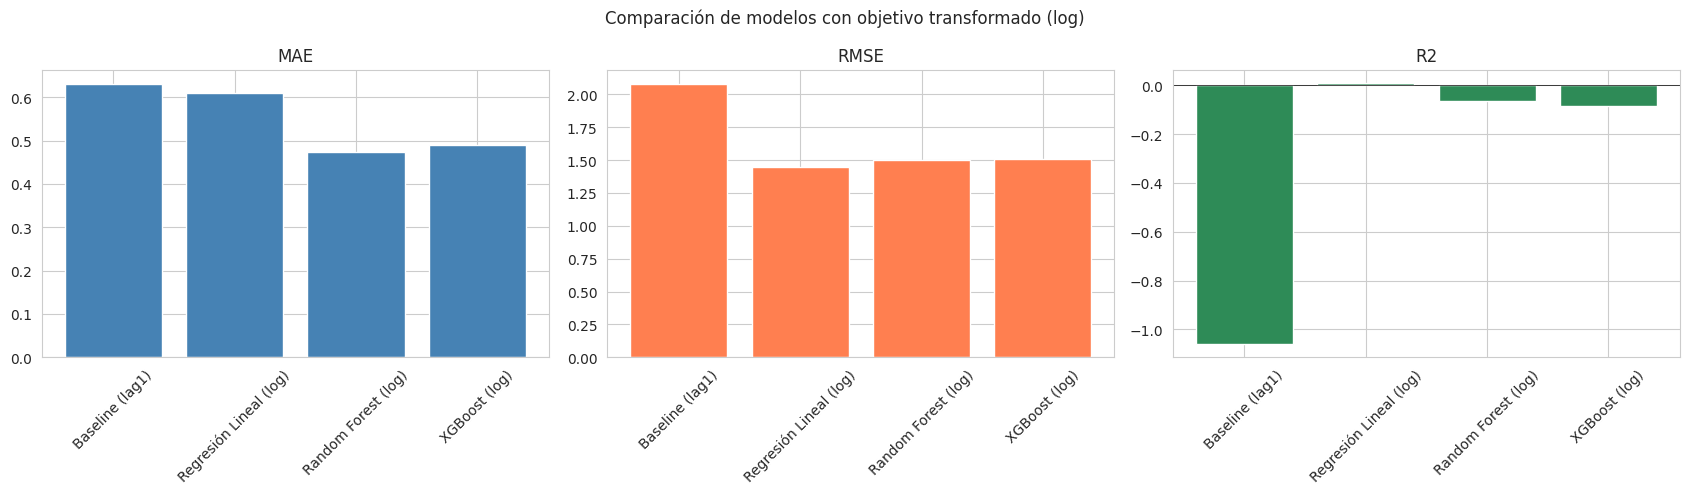

In [ ]:
comparacion = pd.DataFrame(resultados)
print('=== COMPARACIÓN FINAL (Prueba 2023, evaluado en casos reales) ===\n')
print(comparacion.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metrica, color in zip(axes, ['MAE','RMSE','R2'], ['steelblue','coral','seagreen']):
    ax.bar(comparacion['modelo'], comparacion[metrica], color=color)
    ax.set_title(metrica); ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='black', linewidth=0.5)
plt.suptitle('Comparación de modelos con objetivo transformado (log)')
plt.tight_layout(); plt.show()

## 11. Comparación con los resultados SIN transformaciónRecordatorio de los resultados anteriores (sin log) para comparar:

La transformacion logaritmica mejoro considerablemente las metricas en los 3 modelos, Random forest sigue sindos la mejor opcion.
Las variables cambiaron levemente en orden de importancia, Pasando la variable que muestra los casos promedios de las ultimas 4 semanas una de las mas importantes, esto indica que al modificar la escala se aprecia mas la tendencia sostenida que un dato puntual.

## 12. Predicciones vs realidad (mejor modelo)

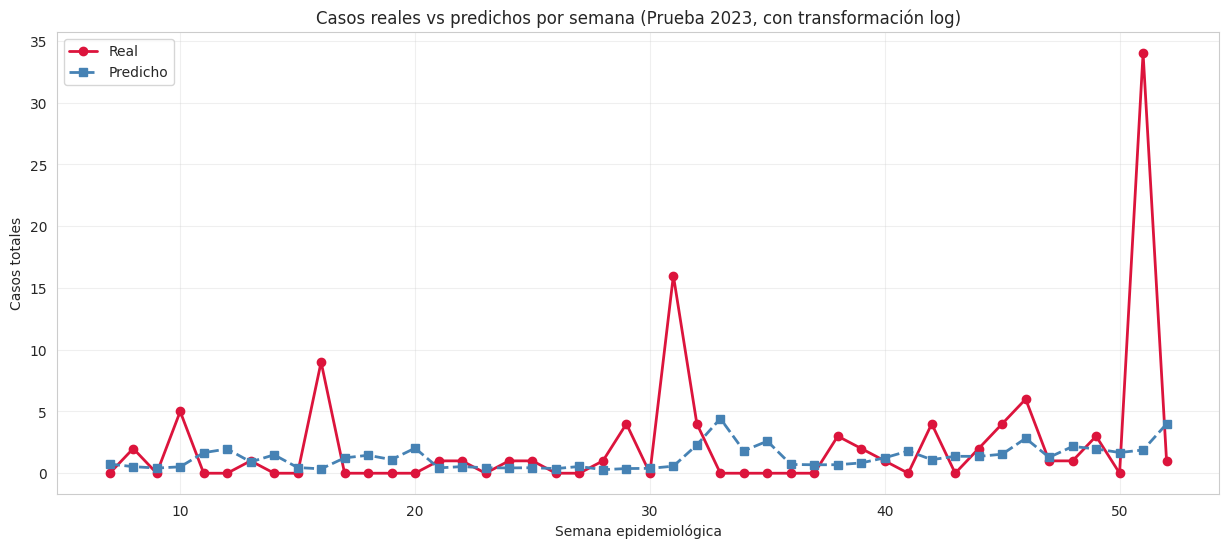

In [ ]:
# Ajusta 'pred_final' al modelo con mejor desempeño
pred_final = pred_rf  # cambia a pred_lr o pred_xgb según resultados

test_plot = test.copy()
test_plot['prediccion'] = pred_final

comp_semana = test_plot.groupby('semana_epi').agg(
    real=('casos_total','sum'),
    predicho=('prediccion','sum')
).reset_index()

plt.figure(figsize=(15, 6))
plt.plot(comp_semana['semana_epi'], comp_semana['real'], marker='o',
         label='Real', color='crimson', linewidth=2)
plt.plot(comp_semana['semana_epi'], comp_semana['predicho'], marker='s',
         label='Predicho', color='steelblue', linewidth=2, linestyle='--')
plt.title('Casos reales vs predichos por semana (Prueba 2023, con transformación log)')
plt.xlabel('Semana epidemiológica'); plt.ylabel('Casos totales')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()